In [2]:
from CPG_RBF import *
import numpy as np
from math import sin,cos,tanh
from matplotlib import pyplot as plt
import torch

In [3]:
def pre_compute_cpg(phi=0.06*np.pi , mi=False):
    # Run for one period
    alpha = 1.01         # SO(2) Alpha term
    if not mi:
        d = phi
        w11   = alpha*cos(d)
        w12   = alpha*sin(d)
        w21   =-w12
        w22   = w11
    
    elif mi:
        w11 = 1.4
        w22 = w11
        w12 = 0.18+phi # 0.18
        w21 = -w12

    x     = []
    y     = []
    t     = []
    t.append(0)
    x.append(-0.197)
    y.append(0.0)
    period = 0
    while y[period] >= y[0]:
        period = period+1
        t.append(period*0.02)
        x.append(tanh(w11*x[period-1]+w12*y[period-1]))
        y.append(tanh(w22*y[period-1]+w21*x[period-1]))
        
    while y[period] <= y[0]:
        period = period+1
        t.append(period*0.02)
        x.append(tanh(w11*x[period-1]+w12*y[period-1]))
        y.append(tanh(w22*y[period-1]+w21*x[period-1]))

    # while t[-1] <= 500:
    #     period = period+1
    #     t.append(period*0.02)
    #     x.append(tanh(w11*x[period-1]+w12*y[period-1]))
    #     y.append(tanh(w22*y[period-1]+w21*x[period-1]))
    period = period
    return t, x, y, period

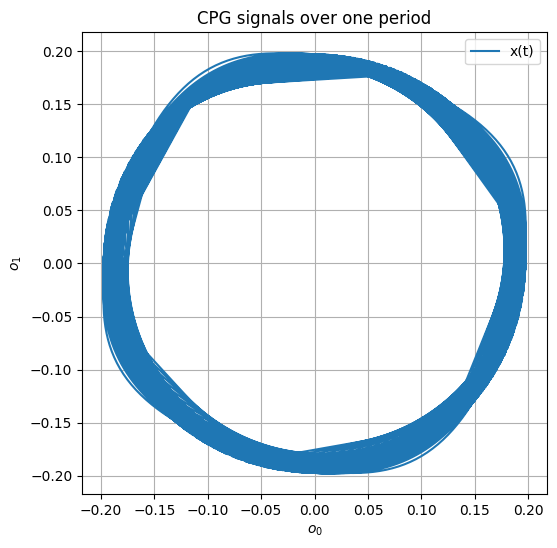

In [10]:
x_ = []
y_ = []
for i in range(0,100):
    t, x, y, period = pre_compute_cpg(phi=0.018+i*0.01 , mi=False)
    x_.append(x)
    y_.append(y)
X = np.concatenate(x_)
Y = np.concatenate(y_)

plt.figure(figsize=(6,6))
plt.plot(X, Y, label='x(t)')
plt.xlabel("$o_0$")
plt.ylabel("$o_1$")
plt.title("CPG signals over one period")
plt.legend()
plt.grid(True)
plt.show()

# plt.figure(figsize=(8,4))
# plt.plot(t, x, label='x(t)')
# plt.plot(t, y, label='y(t)')
# plt.xlabel("t (s)")
# plt.ylabel("Amplitude")
# plt.title("CPG signals over one period")
# plt.legend()
# plt.grid(True)
# plt.show()




## Frequency Analysis

[0.072992700729927, 0.07331378299120234, 0.07352941176470588, 0.07385524372230427, 0.07418397626112759, 0.07451564828614009, 0.07473841554559042, 0.07507507507507508, 0.07541478129713423, 0.075642965204236, 0.07598784194528875, 0.07621951219512195, 0.07656967840735068, 0.07692307692307693, 0.07716049382716049, 0.07751937984496124, 0.07776049766718507, 0.078125, 0.07836990595611286, 0.07861635220125786, 0.07898894154818326, 0.07923930269413629, 0.07961783439490445, 0.07987220447284345, 0.08012820512820512, 0.08051529790660225, 0.08077544426494346, 0.08103727714748785, 0.08130081300813008, 0.08169934640522876, 0.08196721311475409, 0.08223684210526316, 0.08250825082508251, 0.08278145695364239, 0.0831946755407654, 0.08347245409015025, 0.08375209380234507, 0.08403361344537814, 0.08431703204047218, 0.08460236886632826, 0.08488964346349746, 0.08517887563884156, 0.08547008547008546, 0.08576329331046312, 0.08605851979345955, 0.08635578583765112, 0.08665511265164644, 0.08695652173913043, 0.08726

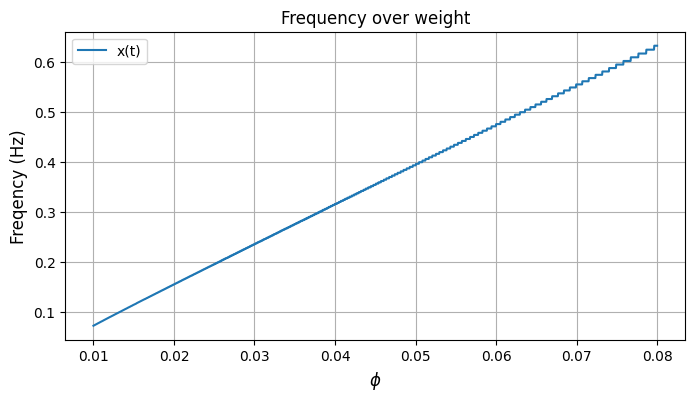

In [13]:
freq = []
w = []
w_range = np.linspace(0.01 , 0.08 , 2000)
for i in w_range:
    d = i
    t, x, y, period = pre_compute_cpg(phi=d)
    w.append(d)
    freq.append(1/t[-1])
print(freq)
plt.figure(figsize=(8,4))
plt.plot(w, freq, label='x(t)')
plt.xlabel("$\phi$" , fontsize=12)
plt.ylabel("Freqency (Hz)", fontsize=12)
plt.title("Frequency over weight")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
for i in range(len(freq)):
    if freq[i] > 0.2495 and freq[i] < 0.252:
        print(w[i] , freq[i])

# 0.038 -> 0.30 Hz
# 0.0318 -> 0.25 Hz

0.03171085542771386 0.25
0.03174587293646824 0.25
0.031780890445222615 0.25
0.03181590795397699 0.25
0.03185092546273137 0.25125628140703515
0.031885942971485746 0.25125628140703515
0.031920960480240124 0.25125628140703515
0.0319559779889945 0.25125628140703515
0.03199099549774888 0.25125628140703515


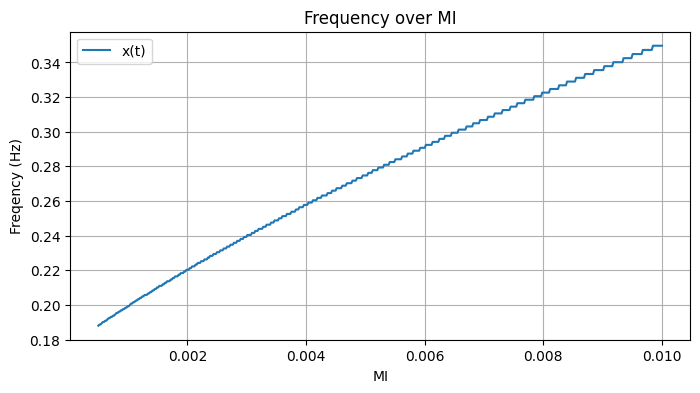

In [6]:
freq = []
w = []
MI_range = np.linspace(0.0005 , 0.01 , 500)
for MI in MI_range:
    t, x, y, period = pre_compute_cpg(phi=MI,mi=True)
    w.append(MI)
    freq.append(1/t[-1])

plt.figure(figsize=(8,4))
plt.plot(w, freq, label='x(t)')
plt.xlabel("MI")
plt.ylabel("Freqency (Hz)")
plt.title("Frequency over MI")
plt.legend()
plt.grid(True)
plt.show()

## RBF net

In [7]:
t, x, y, period = pre_compute_cpg()

num_basis = 20
KENNE  = [0]*num_basis  # Kernels
var = 25
ci = np.asarray(np.around(np.linspace(1, period, num_basis+1)), dtype=int)
ci = ci[:-1]
cx = [0] * (len(ci))
cy = [0] * (len(ci))
for k in range(len(ci)): # Place mean
    cx[k] = x[ci[k]]
    cy[k] = y[ci[k]]
for i in range(num_basis):
    rx   = [q - cx[i] for q in x]
    ry   = [q - cy[i] for q in y]
    KENNE[i] = np.exp(-(np.power((rx),2) + np.power((ry),2))*var)

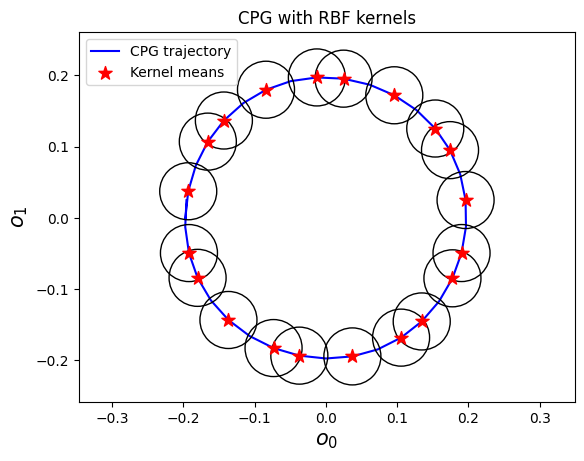

In [8]:
# Plot kernel centers
plt.plot(x, y, color='blue', label='CPG trajectory', zorder=1)
plt.scatter(cx, cy, color='red', marker='*', s=100,
            label='Kernel means', zorder=2)
# Draw circles showing "variance" / width of each kernel
ax = plt.gca()
radius = 0.04   # radius corresponding to e^{-1} of the kernel

for i in range(num_basis):
    circle = plt.Circle((cx[i], cy[i]), radius, fill=False)
    ax.add_patch(circle)

plt.xlabel(r"$o_0$",fontsize=15)
plt.ylabel(r"$o_1$",fontsize=15)
plt.title("CPG with RBF kernels")
plt.legend()
plt.grid(False)
plt.axis('equal')   # keep circles actually circular
plt.show()